<a href="https://colab.research.google.com/github/sungmin-Jeon/financial_practice-/blob/main/notebooks/%EA%B8%88%EC%9C%B5%EB%8D%B0%EC%9D%B4%ED%84%B0%EA%B3%B5%EB%B6%80(Return_and_Realized_Variance).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 분석 개요

본 노트북에서는 금융시계열에서 자주 사용되는 단순 수익률, 로그 수익률, intraday return, variance, volatility, realized variance 및 realized volatility의 개념을 정리하고, 이를 실제 데이터에서 직접 계산해본다.

분석 데이터는 비트코인 5분봉 시계열이며, 하루 288개의 관측치를 기준으로 완전한 날짜만 사용한다. 이를 통해 장중 수익률의 제곱합이 하루의 realized variance로 연결되는 과정을 확인한다.

구체적으로는 데이터 전처리 이후 단순 수익률과 로그 수익률을 비교하고, variance 및 volatility를 정리한 뒤, intraday return 기반의 realized variance와 realized volatility를 계산한다.

---

# 2. 분석 준비

## 2.1 라이브러리 불러오기

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2.2 데이터 불러오기
본 분석에서는 비트코인 5분봉 시계열 데이터를 사용한다.  
데이터에는 시점별 시가, 고가, 저가, 종가, 거래량 등의 정보가 포함되어 있으며, 주요 시간 기준은 `candle_date_time_kst` 컬럼을 따른다.  
이후 분석에서는 수익률 및 realized variance 계산을 위해 시간 순서대로 데이터를 정렬하고, 하루 단위로 완전한 관측치를 갖는 날짜만 사용한다.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/24년2월28_26년2월27일5분봉.csv')
df.head()

,candle_date_time_kst,market,candle_date_time_utc,opening_price,high_price,low_price,trade_price,timestamp,candle_acc_trade_price,candle_acc_trade_volume,unit
0,2024-02-28 14:15:00,KRW-BTC,2024-02-28 05:15:00,78953000.0,78978000.0,78753000.0,78811000.0,1709097599967,2.434258e+09,30.862497,5
1,2024-02-28 14:20:00,KRW-BTC,2024-02-28 05:20:00,78811000.0,78820000.0,78790000.0,78800000.0,1709097899578,8.041964e+08,10.205604,5
2,2024-02-28 14:25:00,KRW-BTC,2024-02-28 05:25:00,78800000.0,78814000.0,78796000.0,78812000.0,1709098199938,9.198200e+08,11.671991,5
3,2024-02-28 14:30:00,KRW-BTC,2024-02-28 05:30:00,78810000.0,78870000.0,78795000.0,78849000.0,1709098499909,7.227084e+08,9.167927,5
4,2024-02-28 14:35:00,KRW-BTC,2024-02-28 05:35:00,78849000.0,78856000.0,78780000.0,78794000.0,1709098799884,8.251410e+08,10.467210,5


---

# 3. 데이터 전처리

In [ ]:
# 시간 정리 및 정렬
df = df.copy()
df['candle_date_time_kst'] = pd.to_datetime(df['candle_date_time_kst'])
df = df.sort_values('candle_date_time_kst').reset_index(drop=True)

# 날짜 컬럼 생성(KST 기준)
df['date'] = df['candle_date_time_kst'].dt.date
df.head()
# 하루치 데이터 갖고 있는것만 남기기
count_per_day = df.groupby('date').size().reset_index(name='n_obs')
valid_dates = count_per_day.loc[count_per_day['n_obs'] == 288, 'date']

df = df[df['date'].isin(valid_dates)].copy()
df = df.sort_values('candle_date_time_kst').reset_index(drop=True)

display(df.head())
print("\n")
display(df.tail())

print("중복 시점 수:", df['candle_date_time_kst'].duplicated().sum())
print("\n결측치 개수:")
display(df.isna().sum())
print("\n일별 관측치 수 확인:")
display(df.groupby('date').size().value_counts())

,candle_date_time_kst,market,candle_date_time_utc,opening_price,high_price,low_price,trade_price,timestamp,candle_acc_trade_price,candle_acc_trade_volume,unit,date
0,2024-02-29 00:00:00,KRW-BTC,2024-02-28 15:00:00,84535000.0,84626000.0,84266000.0,84371000.0,1709132699652,6.566341e+09,77.763923,5,2024-02-29
1,2024-02-29 00:05:00,KRW-BTC,2024-02-28 15:05:00,84378000.0,84539000.0,84200000.0,84527000.0,1709132999589,4.234844e+09,50.207207,5,2024-02-29
2,2024-02-29 00:10:00,KRW-BTC,2024-02-28 15:10:00,84539000.0,84889000.0,84402000.0,84880000.0,1709133299814,6.831932e+09,80.738373,5,2024-02-29
3,2024-02-29 00:15:00,KRW-BTC,2024-02-28 15:15:00,84880000.0,84998000.0,84633000.0,84894000.0,1709133599580,1.191322e+10,140.369458,5,2024-02-29
4,2024-02-29 00:20:00,KRW-BTC,2024-02-28 15:20:00,84894000.0,84912000.0,84539000.0,84650000.0,1709133899841,6.042576e+09,71.331042,5,2024-02-29


,candle_date_time_kst,market,candle_date_time_utc,opening_price,high_price,low_price,trade_price,timestamp,candle_acc_trade_price,candle_acc_trade_volume,unit,date
207067,2026-02-26 23:35:00,KRW-BTC,2026-02-26 14:35:00,98231000.0,98467000.0,97960000.0,98003000.0,1772116799817,1.822777e+09,18.564481,5,2026-02-26
207068,2026-02-26 23:40:00,KRW-BTC,2026-02-26 14:40:00,97978000.0,98162000.0,97876000.0,97900000.0,1772117098447,7.252814e+08,7.401439,5,2026-02-26
207069,2026-02-26 23:45:00,KRW-BTC,2026-02-26 14:45:00,97900000.0,97915000.0,97237000.0,97300000.0,1772117399137,3.941513e+09,40.452182,5,2026-02-26
207070,2026-02-26 23:50:00,KRW-BTC,2026-02-26 14:50:00,97300000.0,97497000.0,97170000.0,97489000.0,1772117699815,1.913665e+09,19.670502,5,2026-02-26
207071,2026-02-26 23:55:00,KRW-BTC,2026-02-26 14:55:00,97500000.0,97894000.0,97464000.0,97707000.0,1772117997126,1.140970e+09,11.676178,5,2026-02-26


중복 시점 수: 0

결측치 개수:


,0
candle_date_time_kst,0
market,0
candle_date_time_utc,0
opening_price,0
high_price,0
low_price,0
trade_price,0
timestamp,0
candle_acc_trade_price,0
candle_acc_trade_volume,0



일별 관측치 수 확인:


,count
288,719


---

# 4. 수익률(return) 이해

## 4.1 단순 수익률
단순 수익률은 직전 시점 대비 가격 변화율을 의미한다.

$
R_{t,i} = \frac{P_{t,i} - P_{t,i-1}}{P_{t,i-1}}
$

여기서 $P(_{t,i}$)는 $(t$)일의 $(i$)번째 시점 가격을 의미한다.  
단순 수익률은 직관적인 해석이 가능하다는 장점이 있어 기본적인 수익률 지표로 자주 사용된다.

본 분석에서는 하루 00:00부터 23:55까지 측정된 5분 간격 가격 데이터를 사용하였다.  
각 날짜는 288개의 가격 포인트로 구성되며, 인접 시점 간 변화율을 계산하므로 하루당 총 287개의 5분 단순 수익률이 생성된다.

In [ ]:
# 날짜별 5분 수익률 계산
df['ret_5m_simple'] = df.groupby('date')['trade_price'].pct_change()
display(df[['candle_date_time_kst', 'date', 'trade_price', 'ret_5m_simple']].head(10))

,candle_date_time_kst,date,trade_price,ret_5m_simple
0,2024-02-29 00:00:00,2024-02-29,84371000.0,NaN
1,2024-02-29 00:05:00,2024-02-29,84527000.0,0.001849
2,2024-02-29 00:10:00,2024-02-29,84880000.0,0.004176
3,2024-02-29 00:15:00,2024-02-29,84894000.0,0.000165
4,2024-02-29 00:20:00,2024-02-29,84650000.0,-0.002874
5,2024-02-29 00:25:00,2024-02-29,84836000.0,0.002197
6,2024-02-29 00:30:00,2024-02-29,84884000.0,0.000566
7,2024-02-29 00:35:00,2024-02-29,84700000.0,-0.002168
8,2024-02-29 00:40:00,2024-02-29,84699000.0,-0.000012
9,2024-02-29 00:45:00,2024-02-29,84818000.0,0.001405


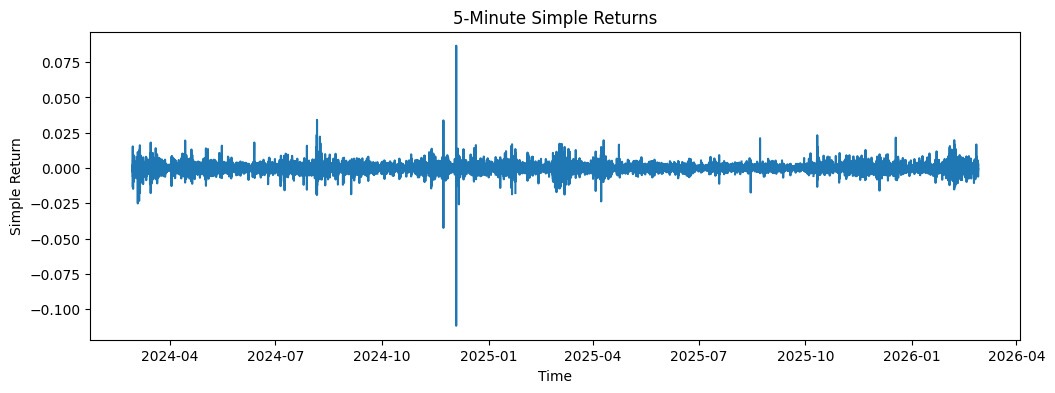

In [ ]:
# 단순수익률 시계열 plot
plt.figure(figsize=(12,4))
plt.plot(df['candle_date_time_kst'], df['ret_5m_simple'])
plt.title('5-Minute Simple Returns')
plt.xlabel('Time')
plt.ylabel('Simple Return')
plt.show()

In [ ]:
# 5분 단순 수익률 기초통계량
display(df['ret_5m_simple'].describe())

# 추가 통계량
display(
    df['ret_5m_simple'].agg([
        'mean',
        'std',
        'min',
        'max',
        'skew',
        'kurt'
    ])
)

,ret_5m_simple
count,206353.000000
mean,0.000001
std,0.001510
min,-0.111728
25%,-0.000588
50%,0.000000
75%,0.000591
max,0.086643


,ret_5m_simple
mean,0.000001
std,0.001510
min,-0.111728
max,0.086643
skew,-1.160397
kurt,299.139136


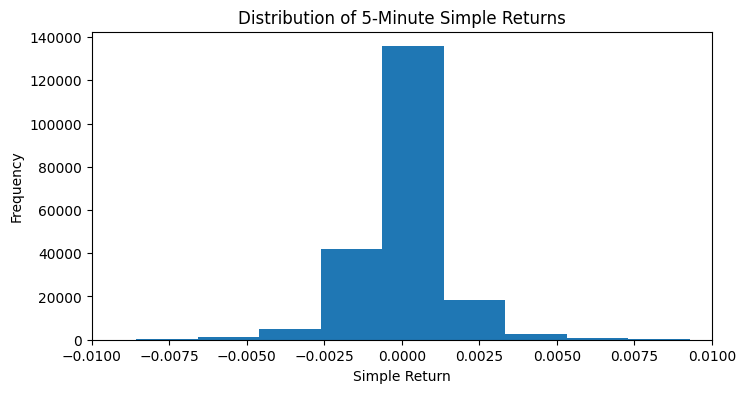

In [ ]:
# 히스토그램
plt.figure(figsize=(8,4))
plt.hist(df['ret_5m_simple'].dropna(), bins=100)
plt.xlim(-0.01, 0.01)
plt.title('Distribution of 5-Minute Simple Returns')
plt.xlabel('Simple Return')
plt.ylabel('Frequency')
plt.show()

### 해석
5분 단순 수익률의 시계열을 확인한 결과, 대부분의 값은 0 근처의 작은 범위에서 움직이는 것으로 나타났다. 실제로 평균과 사분위수도 모두 0에 매우 가깝게 나타나, 장중 5분 단위 가격 변화는 대체로 크지 않음을 확인할 수 있었다.

반면 일부 시점에서는 매우 큰 양수 또는 음수 수익률이 관측되었다. 최소값은 **-0.1117**, 최대값은 **0.0866**으로 나타났으며, 시계열 plot에서도 특정 구간에서 급격한 스파이크가 확인된다. 이는 장중 급격한 가격 변동이나 이상치의 가능성을 시사한다.

또한 왜도(skewness)는 **-1.16**으로 음의 왜도를 보였고, 첨도(kurtosis)는 **299.14**로 매우 크게 나타났다. 이는 5분 단순 수익률 분포가 정규분포보다 훨씬 뾰족하고 꼬리가 두꺼운(fat-tailed) 형태를 가진다는 점을 보여준다.

---

## 4.2 로그 수익률(log return)

로그 수익률(log return)은 현재 가격과 직전 가격의 비율에 자연로그를 취한 값으로 정의된다.

$
r_{t,i} = \log\left(\frac{P_{t,i}}{P_{t,i-1}}\right) = \log(P_{t,i}) - \log(P_{t,i-1})
$

여기서 $P_{t,i}$)는 $(t$)일의 $(i$)번째 시점 가격을 의미한다.  
로그 수익률은 작은 변화에서는 단순 수익률과 거의 유사하지만, 여러 시점에 걸친 수익률을 덧셈 형태로 누적할 수 있다는 장점이 있다.  
이 때문에 금융시계열 분석, 특히 고빈도 수익률 분석과 변동성 측정에서 자주 사용된다.

본 분석에서는 하루 00:00부터 23:55까지 측정된 5분 간격 가격 데이터를 사용하였다.  
각 날짜는 288개의 가격 포인트로 구성되며, 인접 시점 간 로그 차분을 계산하므로 하루당 총 287개의 5분 로그 수익률이 생성된다.

In [ ]:
# 날짜별 5분 로그 수익률 생성
df['ret_5m_log'] = df.groupby('date')['trade_price'].transform(lambda x:np.log(x / x.shift(1)))
display(df[['candle_date_time_kst', 'date', 'trade_price', 'ret_5m_log']].head(10))

,candle_date_time_kst,date,trade_price,ret_5m_log
0,2024-02-29 00:00:00,2024-02-29,84371000.0,NaN
1,2024-02-29 00:05:00,2024-02-29,84527000.0,0.001847
2,2024-02-29 00:10:00,2024-02-29,84880000.0,0.004167
3,2024-02-29 00:15:00,2024-02-29,84894000.0,0.000165
4,2024-02-29 00:20:00,2024-02-29,84650000.0,-0.002878
5,2024-02-29 00:25:00,2024-02-29,84836000.0,0.002195
6,2024-02-29 00:30:00,2024-02-29,84884000.0,0.000566
7,2024-02-29 00:35:00,2024-02-29,84700000.0,-0.002170
8,2024-02-29 00:40:00,2024-02-29,84699000.0,-0.000012
9,2024-02-29 00:45:00,2024-02-29,84818000.0,0.001404


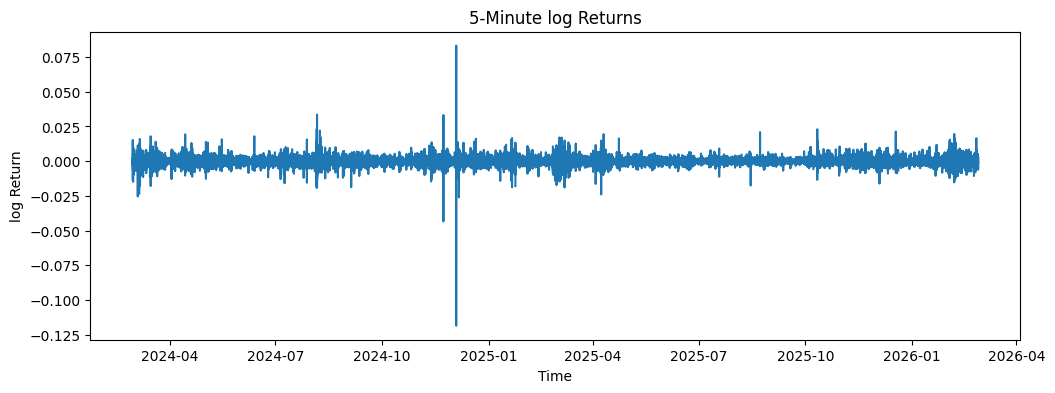

In [ ]:
# 로그수익률 시계열 plot
plt.figure(figsize=(12,4))
plt.plot(df['candle_date_time_kst'], df['ret_5m_log'])
plt.title('5-Minute log Returns')
plt.xlabel('Time')
plt.ylabel('log Return')
plt.show()

In [ ]:
# 5분 로그 수익률 기초통계량
display(df['ret_5m_log'].describe())

# 추가 통계량
display(
    df['ret_5m_log'].agg([
        'mean',
        'std',
        'min',
        'max',
        'skew',
        'kurt'
    ])
)

,ret_5m_log
count,2.063530e+05
mean,3.350070e-07
std,1.512095e-03
min,-1.184769e-01
25%,-5.880520e-04
50%,0.000000e+00
75%,5.908918e-04
max,8.309299e-02


,ret_5m_log
mean,3.350070e-07
std,1.512095e-03
min,-1.184769e-01
max,8.309299e-02
skew,-1.881824e+00
kurt,3.345716e+02


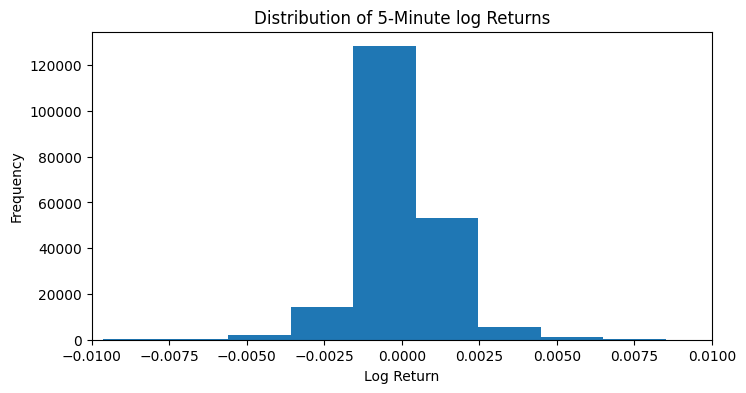

In [ ]:
# 히스토그램
plt.figure(figsize=(8,4))
plt.hist(df['ret_5m_log'].dropna(), bins=100)
plt.xlim(-0.01, 0.01)
plt.title('Distribution of 5-Minute log Returns')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.show()

### 해석
5분 로그 수익률의 시계열을 확인한 결과, 대부분의 값은 0 근처의 작은 범위에서 움직이는 것으로 나타났다. 평균과 사분위수 역시 모두 0에 매우 가까워, 대부분의 5분 단위 가격 변화는 크지 않음을 확인할 수 있었다.

반면 일부 시점에서는 매우 큰 양수 또는 음수 로그 수익률이 관측되었다. 최소값은 -0.1185, 최대값은 0.0831로 나타났으며, 시계열 plot에서도 특정 구간에서 급격한 스파이크가 확인된다. 이는 장중 급격한 가격 변동이 존재했음을 보여준다.

또한 왜도(skewness)는 -1.88로 음의 왜도를 보였고, 첨도(kurtosis)는 334.57로 매우 크게 나타났다. 이는 5분 로그 수익률 분포가 정규분포보다 훨씬 뾰족하고 꼬리가 두꺼운(fat-tailed) 형태를 가진다는 점을 시사한다. 특히 음의 왜도가 단순 수익률보다 더 크게 나타난 것은, 큰 하락 구간에서 로그 수익률이 더 민감하게 반응하기 때문으로 해석할 수 있다.


---

## 4.3 단순 수익률과 로그 수익률 비교

단순 수익률과 로그 수익률은 모두 가격 변화율을 나타내지만 계산 방식에 차이가 있다.

$
R_{t,i} = \frac{P_{t,i}-P_{t,i-1}}{P_{t,i-1}}, \qquad
r_{t,i} = \log\left(\frac{P_{t,i}}{P_{t,i-1}}\right)
$

일반적으로 가격 변화 폭이 작을 때는 두 값이 거의 유사하다.  
하지만 가격 변동이 커질수록 두 값의 차이가 커질 수 있으며, 특히 로그 수익률은 여러 기간에 걸쳐 합산이 가능하다는 장점이 있다.

이 절에서는 실제 5분 데이터에서 단순 수익률과 로그 수익률이 얼마나 유사한지, 그리고 어떤 구간에서 차이가 커지는지를 비교한다.

In [ ]:
compare_stats = pd.DataFrame({
    'simple_return': df['ret_5m_simple'].agg(['mean', 'std', 'min', 'max', 'skew', 'kurt']),
    'log_return': df['ret_5m_log'].agg(['mean', 'std', 'min', 'max', 'skew', 'kurt'])
})

display(compare_stats.T)

,mean,std,min,max,skew,kurt
simple_return,1.477206e-06,0.001510,-0.111728,0.086643,-1.160397,299.139136
log_return,3.350070e-07,0.001512,-0.118477,0.083093,-1.881824,334.571583


In [ ]:
df['ret_diff'] = df['ret_5m_simple'] - df['ret_5m_log']

display(df[['candle_date_time_kst', 'ret_5m_simple', 'ret_5m_log', 'ret_diff']].head(10))
display(df['ret_diff'].describe())

,candle_date_time_kst,ret_5m_simple,ret_5m_log,ret_diff
0,2024-02-29 00:00:00,NaN,NaN,NaN
1,2024-02-29 00:05:00,0.001849,0.001847,1.707253e-06
2,2024-02-29 00:10:00,0.004176,0.004167,8.696039e-06
3,2024-02-29 00:15:00,0.000165,0.000165,1.360090e-08
4,2024-02-29 00:20:00,-0.002874,-0.002878,4.138365e-06
5,2024-02-29 00:25:00,0.002197,0.002195,2.410496e-06
6,2024-02-29 00:30:00,0.000566,0.000566,1.600031e-07
7,2024-02-29 00:35:00,-0.002168,-0.002170,2.352784e-06
8,2024-02-29 00:40:00,-0.000012,-0.000012,6.969580e-11
9,2024-02-29 00:45:00,0.001405,0.001404,9.860543e-07


,ret_diff
count,2.063530e+05
mean,1.142199e-06
std,2.054107e-05
min,0.000000e+00
25%,2.561819e-08
50%,1.737440e-07
75%,7.171515e-07
max,6.749231e-03


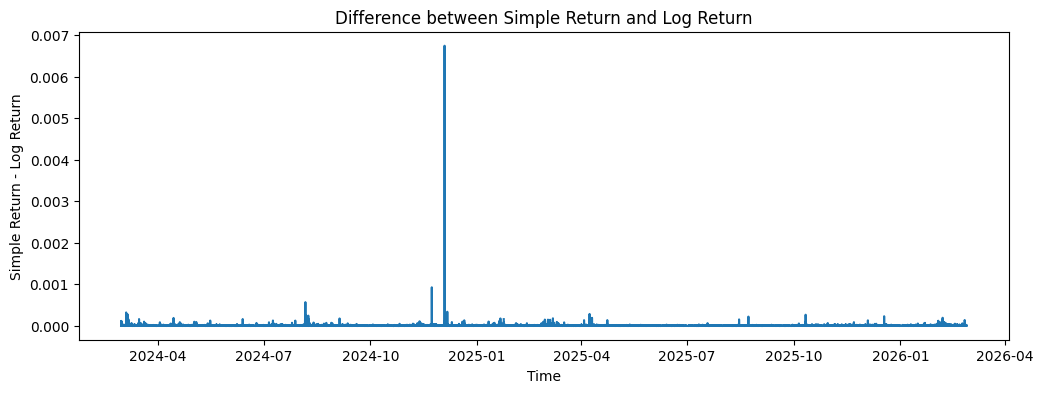

In [ ]:
# 차이 비교
plt.figure(figsize=(12,4))
plt.plot(df['candle_date_time_kst'], df['ret_diff'])
plt.title('Difference between Simple Return and Log Return')
plt.xlabel('Time')
plt.ylabel('Simple Return - Log Return')
plt.show()

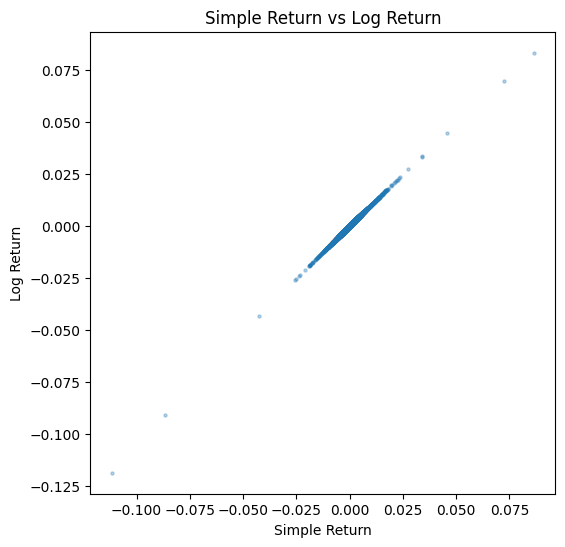

,ret_5m_simple,ret_5m_log
ret_5m_simple,1.000000,0.999908
ret_5m_log,0.999908,1.000000


In [ ]:
# 산점도 및 상관계수
valid = df[['ret_5m_simple', 'ret_5m_log']].dropna()

plt.figure(figsize=(6,6))
plt.scatter(valid['ret_5m_simple'], valid['ret_5m_log'], alpha=0.3, s=5)
plt.title('Simple Return vs Log Return')
plt.xlabel('Simple Return')
plt.ylabel('Log Return')
plt.show()

display(valid[['ret_5m_simple', 'ret_5m_log']].corr())

### 해석
단순 수익률과 로그 수익률의 기초통계량을 비교한 결과, 평균과 표준편차는 거의 유사하게 나타났다. 이는 5분 단위와 같이 매우 짧은 구간에서는 가격 변화율이 작기 때문에 두 수익률이 대부분 비슷한 값을 갖기 때문이다.

실제로 두 수익률의 산점도와 차이 시계열을 확인하면, 대부분의 관측치에서 두 값의 차이는 0에 매우 가깝게 나타난다. 그러나 극단적인 가격 변동이 발생한 일부 시점에서는 단순 수익률과 로그 수익률의 차이가 다소 확대되는 모습을 확인할 수 있다.

따라서 짧은 시간 간격에서는 단순 수익률과 로그 수익률이 거의 동일하게 해석될 수 있지만, 이론적으로는 로그 수익률이 시간에 따라 누적 가능하다는 장점이 있어 금융시계열 분석과 realized variance 계산에 더 자주 활용된다.

# 5. Intraday Return과 Realized Variance


## 5.1 Intraday Return


Intraday return은 하루 거래 시간 내에서 측정된 구간별 수익률을 의미한다.  
예를 들어 1분, 5분, 15분 단위의 수익률이 모두 intraday return이 될 수 있다.

본 분석에서는 비트코인 5분봉 데이터를 사용하므로, 하루 동안 관측된 5분 로그 수익률을 intraday return으로 정의한다.

$
r_{t,i} = \log\left(\frac{P_{t,i}}{P_{t,i-1}}\right)
$

여기서 \(P_{t,i}\)는 \(t\)일의 \(i\)번째 5분 시점 가격을 의미한다.  
각 날짜는 288개의 가격 포인트로 구성되며, 인접 시점 간 로그 차분을 계산하므로 하루당 총 287개의 intraday return이 생성된다.


## 6.2 Realized Variance와 Realized Volatility

Realized variance(RV)는 하루 동안 관측된 intraday return의 제곱합으로 정의된다.  
이는 장중의 세부적인 가격 변동을 누적하여 하루 단위 변동성을 측정하는 대표적인 방법이다.

$
RV_t = \sum_{i=1}^{n_t} r_{t,i}^2
$

여기서 \(r_{t,i}\)는 \(t\)일의 \(i\)번째 intraday return이며, \(n_t\)는 해당 날짜에 계산 가능한 intraday return의 개수이다.

Realized volatility(RVol)는 realized variance의 제곱근으로 정의된다.

$
RVol_t = \sqrt{RV_t}
$

즉, realized variance가 하루 동안의 변동을 제곱합 형태로 누적한 값이라면, realized volatility는 이를 다시 원래 수익률 단위에 가깝게 해석할 수 있도록 변환한 값이라고 볼 수 있다.

본 분석에서는 하루 288개의 가격 포인트로부터 계산된 287개의 5분 로그 수익률을 이용하여 일별 realized variance와 realized volatility를 계산한다.

In [ ]:
daily_rv = (
    df.groupby('date')['ret_5m_log']
    .agg(
        realized_variance=lambda x: np.sum(x.dropna() ** 2),
        realized_volatility=lambda x: np.sqrt(np.sum(x.dropna() ** 2))
    )
    .reset_index()
)

display(daily_rv.head())

,date,realized_variance,realized_volatility
0,2024-02-29,0.003379,0.058131
1,2024-03-01,0.001002,0.031660
2,2024-03-02,0.000492,0.022186
3,2024-03-03,0.000438,0.020932
4,2024-03-04,0.001500,0.038730


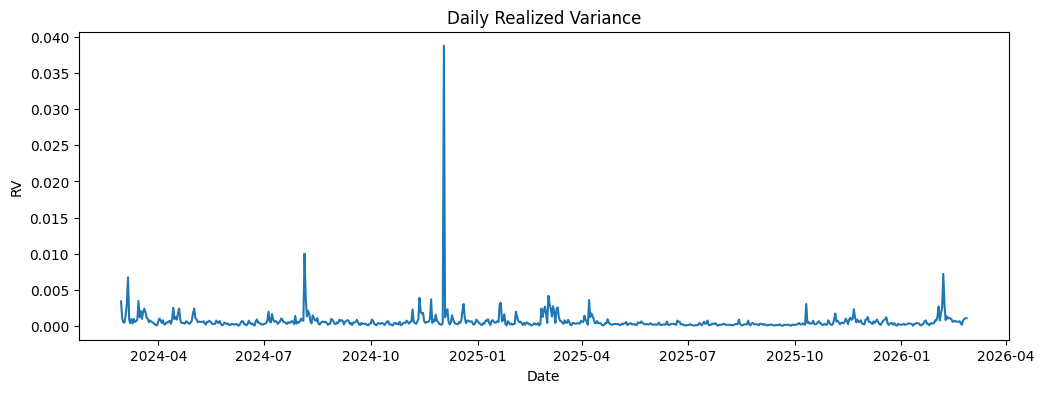

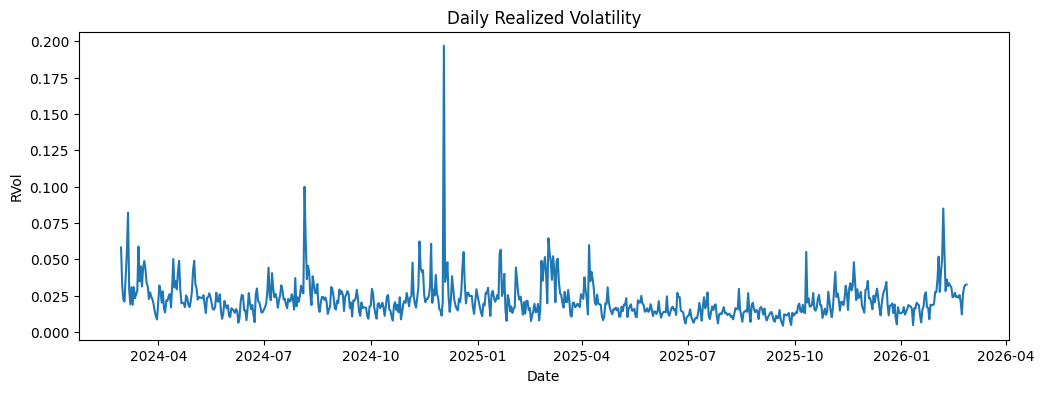

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(daily_rv['date'], daily_rv['realized_variance'])
plt.title('Daily Realized Variance')
plt.xlabel('Date')
plt.ylabel('RV')
plt.show()

plt.figure(figsize=(12,4))
plt.plot(daily_rv['date'], daily_rv['realized_volatility'])
plt.title('Daily Realized Volatility')
plt.xlabel('Date')
plt.ylabel('RVol')
plt.show()

### 해석
일별 realized variance를 계산한 결과, 특정 구간에서 값이 크게 상승하는 모습을 확인할 수 있었다. 이는 해당 날짜들에서 장중 5분 수익률의 변동 폭이 상대적으로 컸음을 의미한다.

Realized volatility는 realized variance의 제곱근이므로 동일한 변동성 정보를 보다 직관적인 스케일에서 보여준다. 따라서 RV와 RVol은 본질적으로 같은 정보를 담고 있지만, 해석 측면에서는 realized volatility가 조금 더 익숙한 형태로 받아들여질 수 있다.

---

# 6. 추가 확인: Realized Variance와 Intraday Return Distribution


## 6-1. RV가 유사한 날자의 intraday return 분포 비교
  - RV가 유사하면 intraday return의 분포가 비슷한게 아닌
  - RV가 유사하더라도 intraday return의 분포가 다른 예를 시각화 함

In [ ]:
ret_col = 'ret_5m_log'

# 전체 데이터 기준 threshold
thr_moderate = df[ret_col].dropna().abs().quantile(0.95)
thr_extreme = df[ret_col].dropna().abs().quantile(0.99)

daily_shape = (
    df.groupby('date')[ret_col]
    .agg(
        rv=lambda x: np.sum(x.dropna() ** 2),
        mean=lambda x: x.dropna().mean(),
        std=lambda x: x.dropna().std(ddof=0),
        kurt=lambda x: x.dropna().kurt(),
        skew=lambda x: x.dropna().skew(),
        min=lambda x: x.dropna().min(),
        max=lambda x: x.dropna().max(),
        max_abs=lambda x: x.dropna().abs().max(),
        iqr=lambda x: x.dropna().quantile(0.75) - x.dropna().quantile(0.25),
        moderate_count=lambda x: (x.dropna().abs() > thr_moderate).sum(),
        extreme_count=lambda x: (x.dropna().abs() > thr_extreme).sum(),
    )
    .reset_index()
)

# outlier형 vs spread형 보조 지표
daily_shape['peak_ratio'] = daily_shape['max_abs'] / (daily_shape['iqr'] + 1e-12)

display(daily_shape.head())

,date,rv,mean,std,kurt,skew,min,max,max_abs,iqr,moderate_count,extreme_count,peak_ratio
0,2024-02-29,0.003379,0.000145,0.003428,3.578590,-0.337125,-0.014876,0.015212,0.015212,0.003475,81,31,4.377683
1,2024-03-01,0.001002,-0.000011,0.001869,2.652529,-0.125790,-0.007737,0.008317,0.008317,0.002281,29,5,3.646860
2,2024-03-02,0.000492,-0.000040,0.001309,1.138918,0.106028,-0.005064,0.004865,0.005064,0.001485,7,0,3.410841
3,2024-03-03,0.000438,0.000008,0.001236,11.929464,0.408952,-0.007287,0.007799,0.007799,0.000806,9,3,9.676843
4,2024-03-04,0.001500,0.000206,0.002277,57.236224,-4.313048,-0.025401,0.011253,0.025401,0.001596,23,6,15.915208


In [ ]:
# z-score 표준화
for col in ['kurt', 'max_abs', 'peak_ratio', 'moderate_count', 'iqr']:
    daily_shape[f'z_{col}'] = (
        (daily_shape[col] - daily_shape[col].mean()) / daily_shape[col].std(ddof=0)
    )

# 값이 클수록 outlier형
daily_shape['shape_score'] = (
    daily_shape['z_kurt']
    + daily_shape['z_max_abs']
    + daily_shape['z_peak_ratio']
    - daily_shape['z_moderate_count']
    - daily_shape['z_iqr']
)

display(
    daily_shape[['date', 'rv', 'kurt', 'max_abs', 'iqr', 'moderate_count', 'shape_score']]
    .head()
)

,date,rv,kurt,max_abs,iqr,moderate_count,shape_score
0,2024-02-29,0.003379,3.578590,0.015212,0.003475,81,-5.240983
1,2024-03-01,0.001002,2.652529,0.008317,0.002281,29,-2.376074
2,2024-03-02,0.000492,1.138918,0.005064,0.001485,7,-0.923114
3,2024-03-03,0.000438,11.929464,0.007799,0.000806,9,3.278261
4,2024-03-04,0.001500,57.236224,0.025401,0.001596,23,11.287976


In [ ]:
rv_tol = 0.05  # 5%
pairs = []

for i, j in combinations(range(len(daily_shape)), 2):
    a = daily_shape.iloc[i]
    b = daily_shape.iloc[j]

    rv_diff_ratio = abs(a['rv'] - b['rv']) / ((a['rv'] + b['rv']) / 2)

    if rv_diff_ratio <= rv_tol:
        pairs.append({
            'date1': a['date'],
            'date2': b['date'],
            'rv1': a['rv'],
            'rv2': b['rv'],
            'rv_diff_ratio': rv_diff_ratio,
            'shape_score_diff': abs(a['shape_score'] - b['shape_score'])
        })

pair_df = pd.DataFrame(pairs)

display(pair_df.sort_values(['shape_score_diff', 'rv_diff_ratio'], ascending=[False, True]).head())

,date1,date2,rv1,rv2,rv_diff_ratio,shape_score_diff
4991,2024-11-22,2025-04-07,0.003676,0.003569,0.029593,25.384748
6158,2025-03-13,2025-08-22,0.000705,0.000714,0.012048,23.953279
5373,2024-12-23,2025-08-22,0.000725,0.000714,0.015506,23.575985
7683,2025-08-22,2025-11-15,0.000714,0.000706,0.010942,23.451564
4740,2024-11-01,2025-08-22,0.000715,0.000714,0.002192,23.365040


In [ ]:
best_pair = pair_df.sort_values(
    ['shape_score_diff', 'rv_diff_ratio'],
    ascending=[False, True]
).iloc[0]

best_pair

,4991
date1,2024-11-22
date2,2025-04-07
rv1,0.003676
rv2,0.003569
rv_diff_ratio,0.029593
shape_score_diff,25.384748


In [ ]:
date1 = best_pair['date1']
date2 = best_pair['date2']

row1 = daily_shape.loc[daily_shape['date'] == date1].iloc[0]
row2 = daily_shape.loc[daily_shape['date'] == date2].iloc[0]

if row1['shape_score'] > row2['shape_score']:
    outlier_day = date1
    spread_day = date2
else:
    outlier_day = date2
    spread_day = date1

print("Outlier-type day :", outlier_day)
print("Spread-type day  :", spread_day)

display(
    daily_shape.loc[daily_shape['date'].isin([outlier_day, spread_day]),
                    ['date', 'rv', 'kurt', 'max_abs', 'iqr', 'moderate_count', 'extreme_count', 'shape_score']]
    .sort_values('shape_score', ascending=False)
)

Outlier-type day : 2024-11-22
Spread-type day  : 2025-04-07


,date,rv,kurt,max_abs,iqr,moderate_count,extreme_count,shape_score
264,2024-11-22,0.003676,99.720831,0.043347,0.001663,16,5,22.145847
397,2025-04-07,0.003569,8.378412,0.023930,0.003646,88,29,-3.238900


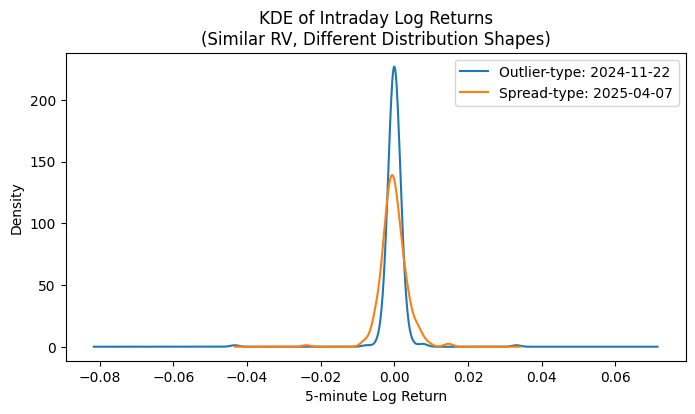

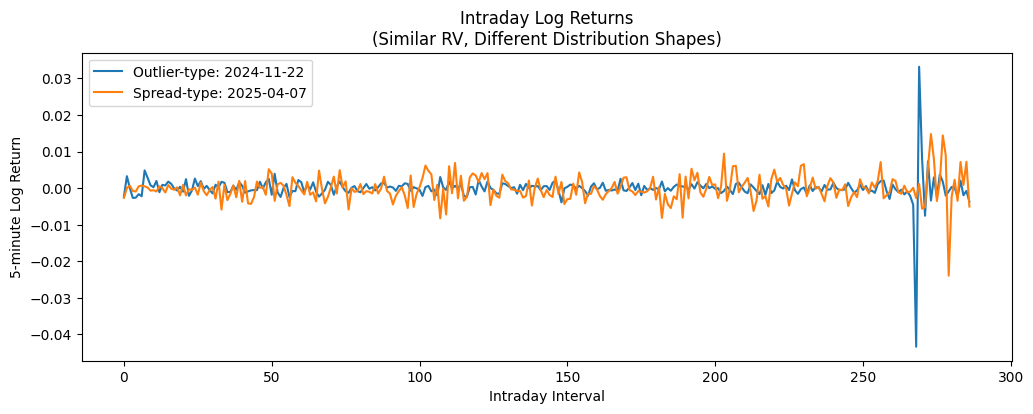

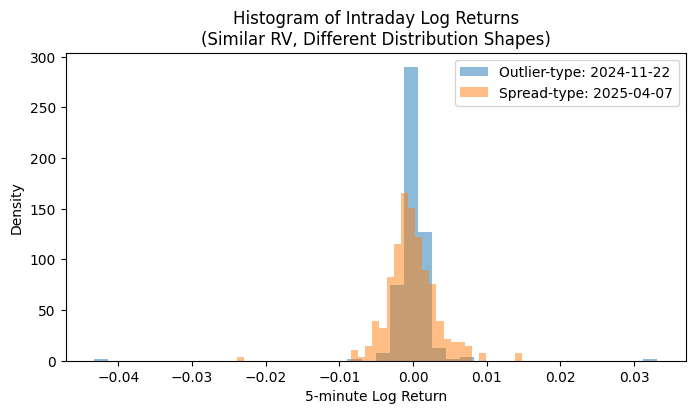

In [ ]:
ret_outlier = df.loc[df['date'] == outlier_day, ret_col].dropna()
ret_spread  = df.loc[df['date'] == spread_day, ret_col].dropna()

plt.figure(figsize=(8, 4))
ret_outlier.plot(kind='kde', label=f'Outlier-type: {outlier_day}')
ret_spread.plot(kind='kde', label=f'Spread-type: {spread_day}')
plt.title('KDE of Intraday Log Returns\n(Similar RV, Different Distribution Shapes)')
plt.xlabel('5-minute Log Return')
plt.ylabel('Density')
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(ret_outlier.values, label=f'Outlier-type: {outlier_day}')
plt.plot(ret_spread.values, label=f'Spread-type: {spread_day}')
plt.title('Intraday Log Returns\n(Similar RV, Different Distribution Shapes)')
plt.xlabel('Intraday Interval')
plt.ylabel('5-minute Log Return')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(ret_outlier, bins=40, alpha=0.5, density=True, label=f'Outlier-type: {outlier_day}')
plt.hist(ret_spread, bins=40, alpha=0.5, density=True, label=f'Spread-type: {spread_day}')
plt.title('Histogram of Intraday Log Returns\n(Similar RV, Different Distribution Shapes)')
plt.xlabel('5-minute Log Return')
plt.ylabel('Density')
plt.legend()
plt.show()

### 해석
RV가 유사한 날짜들 중에서도 intraday return distribution의 형태는 서로 다르게 나타날 수 있다.  
이를 확인하기 위해 realized variance 차이가 작은 날짜쌍을 먼저 선택한 뒤, 각 날짜의 intraday return 분포 shape 차이가 크게 나타나는 pair를 비교하였다.

그 결과, 한 날짜는 대부분의 수익률이 0 근처에 집중되어 있으나 일부 큰 outlier가 두드러지는 반면, 다른 날짜는 극단값은 상대적으로 덜하지만 전반적으로 더 넓게 퍼진 분포를 보일 수 있었다.  
이는 realized variance가 하루의 변동성을 하나의 숫자로 요약하는 과정에서 intraday return distribution의 세부 구조를 충분히 반영하지 못할 수 있음을 보여준다.

## 6-2. RV가 큰 날과 작은 날의 intraday return 분포 비교

In [ ]:
max_day = daily_rv.loc[daily_rv['realized_variance'].idxmax(), 'date']
min_day = daily_rv.loc[daily_rv['realized_variance'].idxmin(), 'date']

print("RV가 가장 큰 날:", max_day)
print("RV가 가장 작은 날:", min_day)

display(
    daily_rv[daily_rv['date'].isin([max_day, min_day])]
    .sort_values('realized_variance', ascending=False)
)

RV가 가장 큰 날: 2024-12-03
RV가 가장 작은 날: 2025-09-21


,date,realized_variance,realized_volatility
275,2024-12-03,0.038804,0.196986
562,2025-09-21,0.000018,0.004263


In [ ]:
# 해당 날짜의 intraday log return 추출
ret_max = df.loc[df['date'] == max_day, 'ret_5m_log'].dropna()
ret_min = df.loc[df['date'] == min_day, 'ret_5m_log'].dropna()

print(f"{max_day} intraday return 개수:", len(ret_max))
print(f"{min_day} intraday return 개수:", len(ret_min))

2024-12-03 intraday return 개수: 287
2025-09-21 intraday return 개수: 287


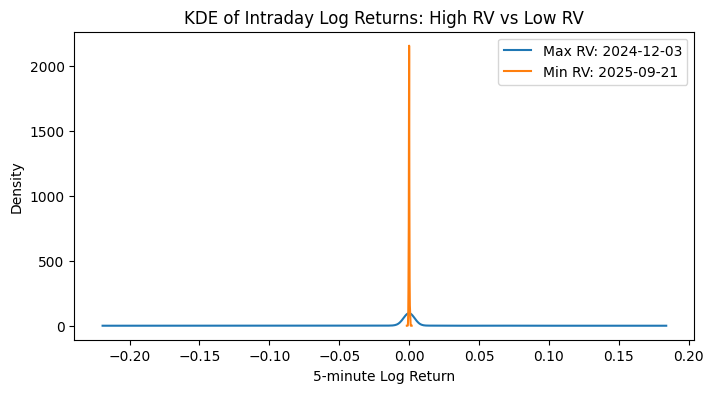

In [ ]:
# 1) KDE 비교
plt.figure(figsize=(8, 4))
ret_max.plot(kind='kde', label=f'Max RV: {max_day}')
ret_min.plot(kind='kde', label=f'Min RV: {min_day}')
plt.title('KDE of Intraday Log Returns: High RV vs Low RV')
plt.xlabel('5-minute Log Return')
plt.ylabel('Density')
plt.legend()
plt.show()

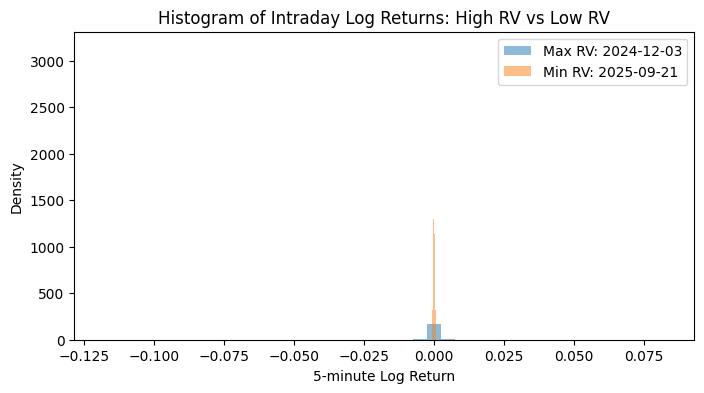

In [ ]:
# 2) 히스토그램 비교
plt.figure(figsize=(8, 4))
plt.hist(ret_max, bins=40, alpha=0.5, density=True, label=f'Max RV: {max_day}')
plt.hist(ret_min, bins=40, alpha=0.5, density=True, label=f'Min RV: {min_day}')
plt.title('Histogram of Intraday Log Returns: High RV vs Low RV')
plt.xlabel('5-minute Log Return')
plt.ylabel('Density')
plt.legend()
plt.show()

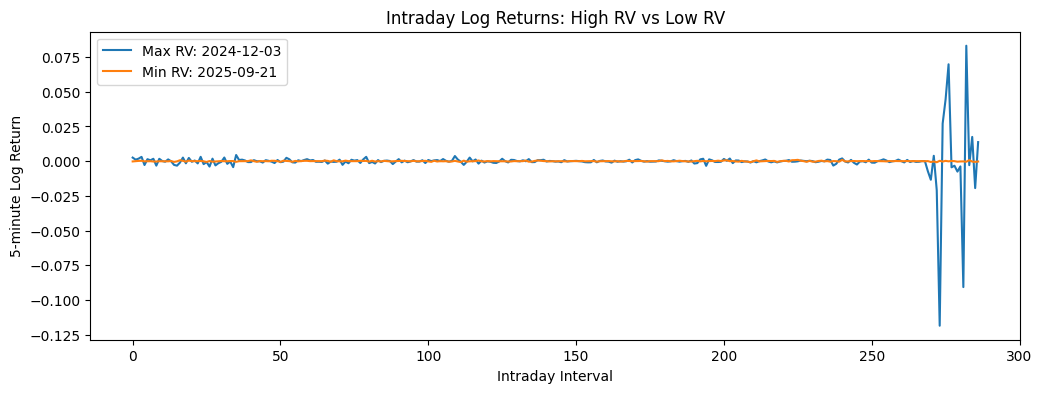

In [ ]:
# 3) intraday 시계열 비교
plt.figure(figsize=(12, 4))
plt.plot(ret_max.values, label=f'Max RV: {max_day}')
plt.plot(ret_min.values, label=f'Min RV: {min_day}')
plt.title('Intraday Log Returns: High RV vs Low RV')
plt.xlabel('Intraday Interval')
plt.ylabel('5-minute Log Return')
plt.legend()
plt.show()

In [ ]:
# 4) 두 날짜의 기초 통계 비교
compare_high_low = pd.DataFrame({
    str(max_day): ret_max.agg(['mean', 'std', 'min', 'max', 'skew', 'kurt']),
    str(min_day): ret_min.agg(['mean', 'std', 'min', 'max', 'skew', 'kurt'])
})

display(compare_high_low)

,2024-12-03,2025-09-21
mean,-0.000145,-0.000017
std,0.011647,0.000251
min,-0.118477,-0.000784
max,0.083093,0.000938
skew,-3.080482,0.426251
kurt,62.955908,1.816086


### 해석
RV가 가장 큰 날과 가장 작은 날의 intraday return 분포를 비교한 결과, realized variance가 하루 동안의 장중 변동 크기를 잘 요약하고 있음을 확인할 수 있었다. RV가 가장 작은 날인 2025-09-21은 대부분의 5분 로그수익률이 0 근처에 매우 밀집되어 있었으며, 분포도 매우 좁고 안정적인 형태를 보였다.

반면 RV가 가장 큰 날인 2024-12-03은 분포가 훨씬 넓게 퍼져 있었고, 시계열에서도 장중 후반부에 매우 큰 양수 및 음수 스파이크가 집중적으로 나타났다. 기초통계량에서도 표준편차, 최소값, 최대값의 절대 크기가 매우 크게 나타났으며, 왜도는 -3.08, 첨도는 62.96으로 강한 음의 비대칭성과 fat-tail 특성을 보였다.

특히 2024-12-03은 사용자가 언급한 계엄 관련 이벤트가 있었던 날짜로, 해당 외부 충격이 장중 수익률 급변동과 높은 realized variance로 반영되었을 가능성을 시사한다. 이 결과는 realized variance가 단순한 요약 지표이지만, 실제로는 장중의 큰 이벤트성 충격과 수익률 분포의 급격한 변화를 포착할 수 있음을 보여준다.